In [1]:
%pip install numpy pandas matplotlib seaborn

# Importação com os aliases convencionais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# O 'taxon.txt' é o coração do dataset
df = pd.read_csv('taxon.txt', sep='\t', low_memory=False)

# Ver as colunas disponíveis
print(df.columns)

Index(['id', 'taxonID', 'acceptedNameUsageID', 'parentNameUsageID',
       'originalNameUsageID', 'scientificName', 'acceptedNameUsage',
       'parentNameUsage', 'namePublishedIn', 'namePublishedInYear',
       'higherClassification', 'kingdom', 'phylum', 'class', 'order', 'family',
       'genus', 'specificEpithet', 'infraspecificEpithet', 'taxonRank',
       'scientificNameAuthorship', 'taxonomicStatus', 'nomenclaturalStatus',
       'modified', 'bibliographicCitation', 'references'],
      dtype='str')


### Análise Exploratória Aplicada (EDA)
Com base nos conceitos estruturais estudados no caderno de `PythonParaDados`, a análise realiza três grandes passos na base da Flora Brasileira:
1. **Inspeção Rápida:** Verificar dimensionalidades, colunas alvo e dados nulos.
2. **Filtros e Agrupamentos:** Filtrar apenas "Nomes Aceitos" e agrupar para descobrir as Famílias mais diversas.
3. **Visualização:** Englobar a análise de agrupamento e de distribuição no tempo em uma figura Matplotlib com múltiplos subplots.

In [3]:
# Inspeção Rápida e Auditoria de Dados

colunas_foco = ['family', 'genus', 'scientificName', 'taxonomicStatus', 'namePublishedInYear']
df_foco = df[colunas_foco]

print("--- Formato Inicial do Dataset ---")
print(df_foco.shape)  # O tamanho (linhas, colunas)

print("\n--- Auditoria (Nulos e Tipos) ---")
display(df_foco.info())

print("\n--- Contagem de Valores Nulos nas Colunas Chave ---")
print(df_foco.isna().sum())

--- Formato Inicial do Dataset ---
(154898, 5)

--- Auditoria (Nulos e Tipos) ---
<class 'pandas.DataFrame'>
RangeIndex: 154898 entries, 0 to 154897
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   family               145599 non-null  str  
 1   genus                154136 non-null  str  
 2   scientificName       154898 non-null  str  
 3   taxonomicStatus      151554 non-null  str  
 4   namePublishedInYear  38942 non-null   str  
dtypes: str(5)
memory usage: 5.9 MB


None


--- Contagem de Valores Nulos nas Colunas Chave ---
family                   9299
genus                     762
scientificName              0
taxonomicStatus          3344
namePublishedInYear    115956
dtype: int64


In [4]:
# Passo 2: Filtros Booleanos e Agrupamentos (Groupby)

print("--- Visualizando a Categoria de Nomes (Aceitos vs Outros) ---")

# O groupby é utilizado para extrair o tamanho (.size()) de cada categoria
resumo_status = df_foco.groupby('taxonomicStatus').size()
display(resumo_status)

# Fatiamento via Máscara Booleana: A pesquisa foca APENAS em nomes aceitos
df_aceitos = df_foco[df_foco['taxonomicStatus'] == 'NOME_ACEITO']

print("\n--- Top 10 Famílias com Maior Variedade de Espécies (Nomes Aceitos) ---")

# Agrupa-se também por família, classificando em ordem decrescente
top_familias = df_aceitos.groupby('family').size().sort_values(ascending=False).head(10)
display(top_familias)

--- Visualizando a Categoria de Nomes (Aceitos vs Outros) ---


taxonomicStatus
NOME_ACEITO    66767
SINONIMO       84787
dtype: int64


--- Top 10 Famílias com Maior Variedade de Espécies (Nomes Aceitos) ---


family
Fabaceae           4060
Orchidaceae        3212
Asteraceae         2821
Incertae sedis     2001
Poaceae            1960
Rubiaceae          1674
Melastomataceae    1590
Bromeliaceae       1586
Myrtaceae          1287
Apocynaceae        1206
dtype: int64

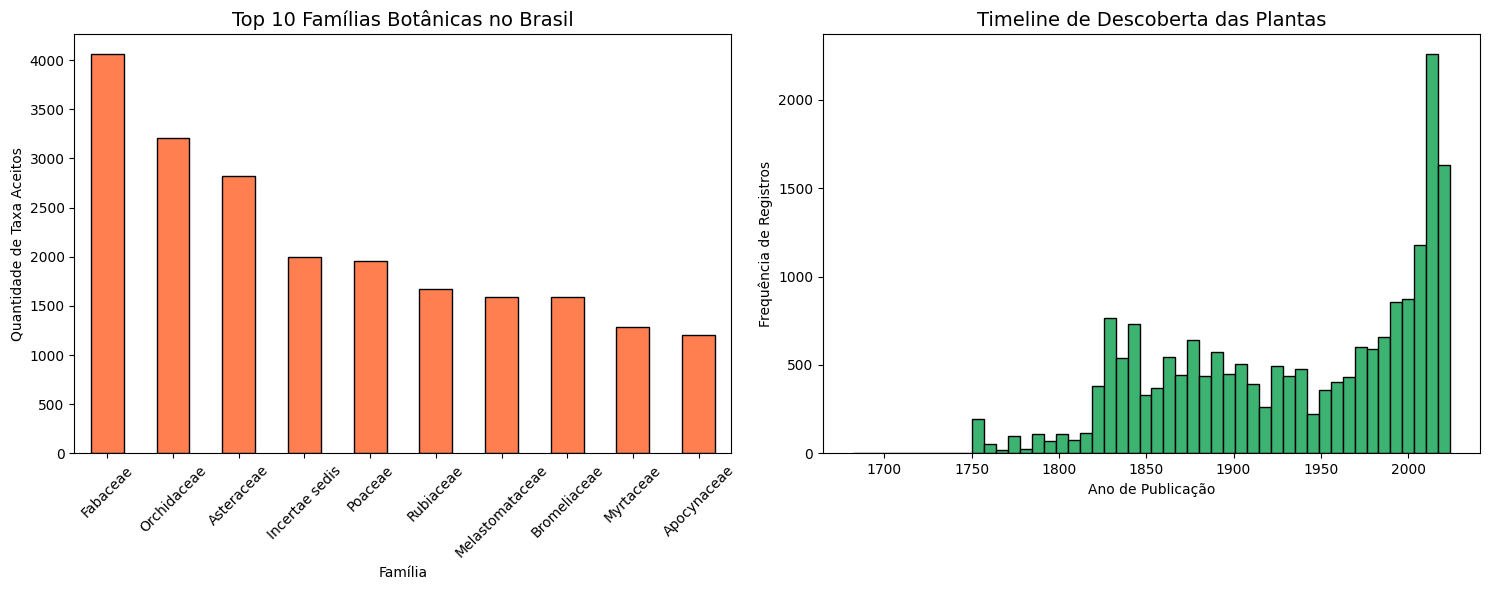

In [5]:
# 3: Visualização Combinada com Matplotlib (Subplots e Gráficos de Base)

# É criada uma figura customizada comportando 2 gráficos paralelos (1 linha, 2 colunas)
plt.figure(figsize=(15, 6))

# Gráfico 1: Gráfico de Barras com as Maiores Famílias
plt.subplot(1, 2, 1)
top_familias.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Famílias Botânicas no Brasil', fontsize=14)
plt.ylabel('Quantidade de Taxa Aceitos')
plt.xlabel('Família')
plt.xticks(rotation=45)

# Gráfico 2: Histograma de Publicações ao Longo dos Anos
plt.subplot(1, 2, 2)
# Limpeza prévia: Anos devem ser numéricos (forçando nulos em strings ilegíveis com 'coerce')
anos_limpos = pd.to_numeric(df_aceitos['namePublishedInYear'], errors='coerce').dropna()

# Filtro para analisar apenas registros de descobrimento contados a partir do ano 1500
anos_limpos = anos_limpos[anos_limpos >= 1500]

# Histograma mostrando em quais épocas mais plantas foram descobertas/publicadas
plt.hist(anos_limpos, bins=50, color='mediumseagreen', edgecolor='black')
plt.title('Timeline de Descoberta das Plantas', fontsize=14)
plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência de Registros')

# Ajusta o espaçamento do subplots e plota na tela
plt.tight_layout()
plt.show()